In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data['date'] = pd.to_datetime(data['date'])   # Convert date

In [5]:
data = data.sort_values('date') # sorting data

In [7]:
data.fillna(method='ffill', inplace=True) #handling missing values here

/tmp/ipykernel_12665/3889470264.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True) #handling missing values here


In [8]:
data.drop_duplicates(inplace=True) #Remove duplicates

In [9]:
#Filter one company
df = data[data['Name'] == 'AAPL']
df.set_index('date', inplace=True)

In [10]:
#here feature engineering is done
df['Daily_Return'] = df['close'].pct_change()
df['Month'] = df.index.month
df['Year'] = df.index.year

/tmp/ipykernel_12665/3065821120.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Daily_Return'] = df['close'].pct_change()
/tmp/ipykernel_12665/3065821120.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df.index.month
/tmp/ipykernel_12665/3065821120.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

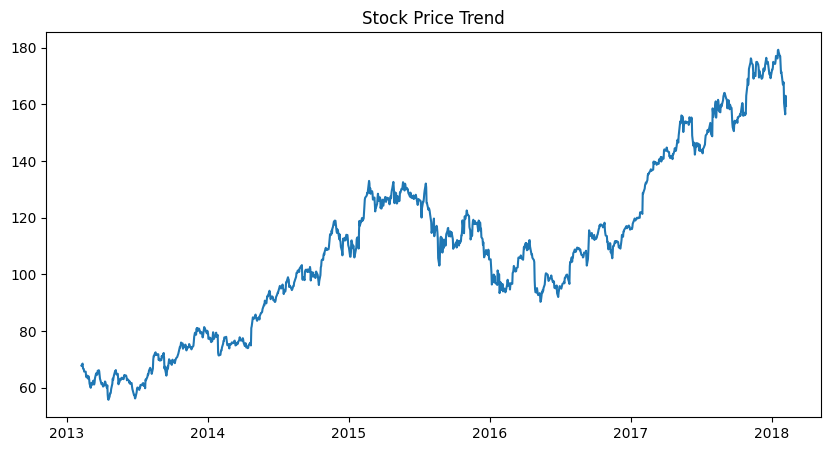

In [12]:
#EDA is done, which shows stock price trend
plt.figure(figsize=(10,5))
plt.plot(df['close'])
plt.title("Stock Price Trend")
plt.show()

/tmp/ipykernel_12665/2946487485.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA50'] = df['close'].rolling(50).mean()
/tmp/ipykernel_12665/2946487485.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA200'] = df['close'].rolling(200).mean()


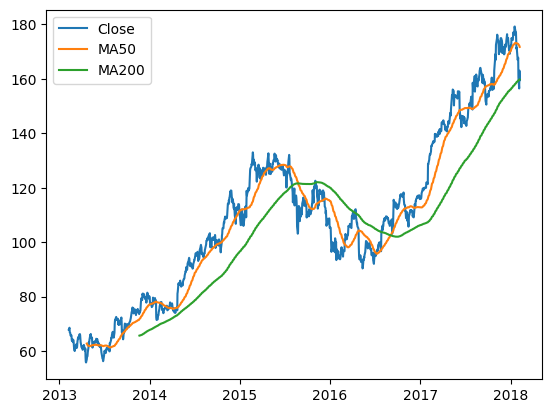

In [16]:
#Moving Average
df['MA50'] = df['close'].rolling(50).mean()
df['MA200'] = df['close'].rolling(200).mean()

plt.plot(df['close'], label='Close')
plt.plot(df['MA50'], label='MA50')
plt.plot(df['MA200'], label = 'MA200')
plt.legend()
plt.show()

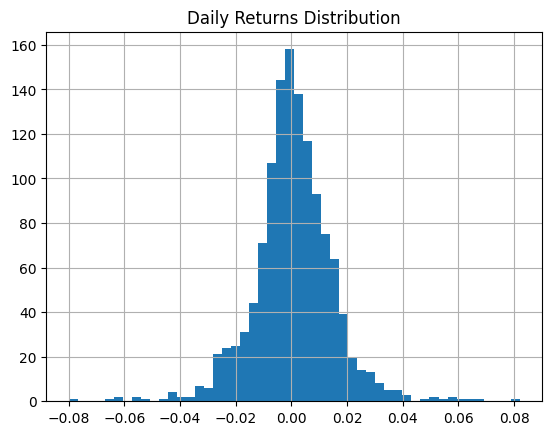

In [14]:
#Daily Returns
df['Daily_Return'].hist(bins=50)
plt.title("Daily Returns Distribution")
plt.show()

In [18]:
#Forecasting
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(df['close'], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)
print(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


1259    159.127683
1260    158.960932
1261    159.111165
1262    159.126345
1263    159.061677
1264    159.048456
1265    159.051535
1266    159.055102
1267    159.053708
1268    159.052261
1269    159.052135
1270    159.052326
1271    159.052361
1272    159.052298
1273    159.052270
1274    159.052274
1275    159.052279
1276    159.052278
1277    159.052277
1278    159.052276
1279    159.052276
1280    159.052277
1281    159.052277
1282    159.052276
1283    159.052276
1284    159.052276
1285    159.052276
1286    159.052276
1287    159.052276
1288    159.052276
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


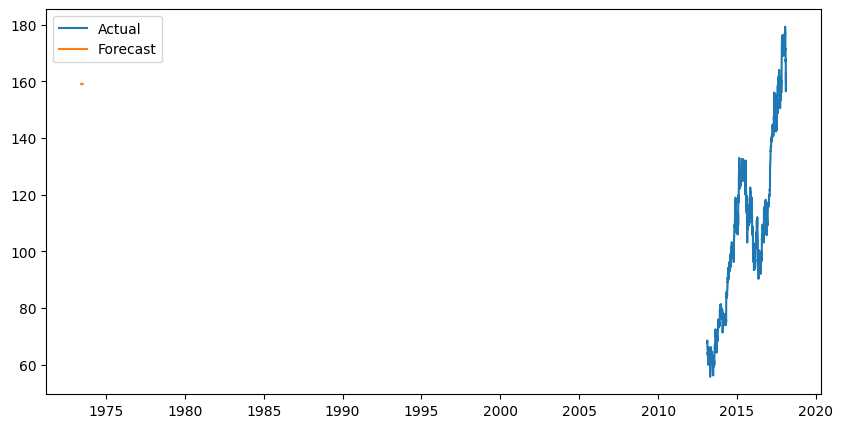

In [19]:
plt.figure(figsize=(10,5))
plt.plot(df['close'], label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()

In [20]:
df.to_csv('/content/cleaned_data.csv')